# LSM Benchmarking with TCSPC

## Goal


## Approach & Measurement Setup




### .PTU Decoding

Function routines for decoding PicoQuant .ptu files.

In [5]:
# Importing modules
import sys, struct, io, os
import math
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
%matplotlib inline

# Setting up matplotlib for larger plots and retina resolution
from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16


# File path to .ptu file to be analysed
ptupath = '../notebooks/data/HyD_LongTime_Test_12.ptu'


In [6]:
# Functions for ptu record decoding
@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(
    recordarray: 4 x numRec NumPy array holding raw 32 bit photon records in ['record']
    macrotimefactor: multiplication factor for mactotime clock to recover real experiment macrotime
    )
    Output is recordarray, but with populated ['macrotime'] row
    
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
    return(recordarray)


In [7]:
# Record and header type definitions
tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

rtHydraHarp2T3 = struct.unpack(">i", bytes.fromhex('01010304'))[0]


# Open file defined in ptupath
ptureadstream = open(ptupath, 'rb')

# Checking file magic and version
filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

if(filemagic != 'PQTTTR'):
    print('%s is not a .ptu file!' % ptupath)
    ptureadstream.close()
else:
    print('%s is a valid .ptu file... Commencing.' % ptupath)

fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
print('File Version: %s' % fileversion)


## Decoding Header
## setting up header end string to terminate header decoding in while loop 
headerend_tag = 'Header_End'
reached_headerend = False


# tuple that stores decoded information from header section
header_contents = {}

# decoding header
while(reached_headerend == False):
    headerpiece = ptureadstream.read(48)
    tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
    tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
    tagType = struct.unpack('<i', headerpiece[36:40])[0]
    tagVal = headerpiece[40:48]
    
    if(tagId == headerend_tag):
        reached_headerend = True
        ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
        print('Found Header_End.')
        break
    
    if(tagType == tyEmpty8):
        header_contents['Empty'] =  'Empty'
        
    elif(tagType == tyBool8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyInt8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8):
        value = struct.unpack('<d', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8Array):
        value = struct.unpack("<q", tagVal)[0]
        print('Float array with %d entries' % value / 8)
        
    elif(tagType == tyAnsiString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('latin1').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyWideString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyBinaryBlob):
        value = struct.unpack("<q", tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyBitSet64):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyColor8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  "{0:#0{1}x}".format(value,18)
        
    elif(tagType == tyBinaryBlob):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value

    elif(tagType == tyTDateTime):
        print(' ')
        
    else:
        continue
        #print('Unknown header tag type. Ignored.')
        
    
headerend_bitoffset = ptureadstream.tell() # Needed to quickly jump to photon records instead of header
    
print('Finished decoding header.')

# Copying header info into FLIMInfo dict
FLIMInfo = {
    #'Filename' : header_contents['$Filename'],
    #'Comment': header_contents['$Comment'],
    'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
    'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
    #'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
    'PixelsX' : header_contents['ImgHdr_PixX'],
    'PixelsY' : header_contents['ImgHdr_PixY'],
    'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
    'BaseResolution' : header_contents['HW_BaseResolution'],
    'Resolution' : header_contents['MeasDesc_Resolution'],
    'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
    'SyncRate' : header_contents['TTResult_SyncRate'],
    'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
}

# Closing read stream
ptureadstream.close()


# Reading photon records from ptu file, reopening read stream at headerend_bitoffset
## Initializing record array with pre-defined data types and length (read from header -> NumberOfRecords)
recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8),
                              ('nanotime', np.float64), ('macrotime', np.float64)])
recordarray = np.zeros(
        shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

## Getting macro and nano time conversion factors from FLIMInfo
macroMultFactor = FLIMInfo['GlobalResolution']
nanoMultFactor = FLIMInfo['Resolution'] * 1e9

## Dumping records into recordarray
with open(ptupath, 'rb') as file:
    file.seek(headerend_bitoffset)
    recordarray[:]['record'] = np.fromfile(file, dtype=np.uint32)
    file.close()
    
## Recover marker signals and nano times by bitwise operations on recordarray['record']
recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor

# Recover macro times using treatOverflows()
recordarray = treatOverflows(recordarray, macroMultFactor)

# Delete raw bit records from recordarray (['record'])
macrotimes = np.array(recordarray['macrotime'], dtype = np.float64)
nanotimes = np.array(recordarray['nanotime'], dtype = np.float64)
markers = np.array(recordarray['marker'], dtype = np.uint8)
del recordarray

print('\n*********\nFinished decoding .ptu file. recordarray can now be used.')

../notebooks/data/HyD_LongTime_Test_12.ptu is a valid .ptu file... Commencing.
File Version: 1.0.00
 
Found Header_End.
Finished decoding header.

*********
Finished decoding .ptu file. recordarray can now be used.


## Data Analysis

In [31]:
# Count microscope events
num_LineStarts = np.sum(markers == 3)
print(num_LineStarts)

2022627


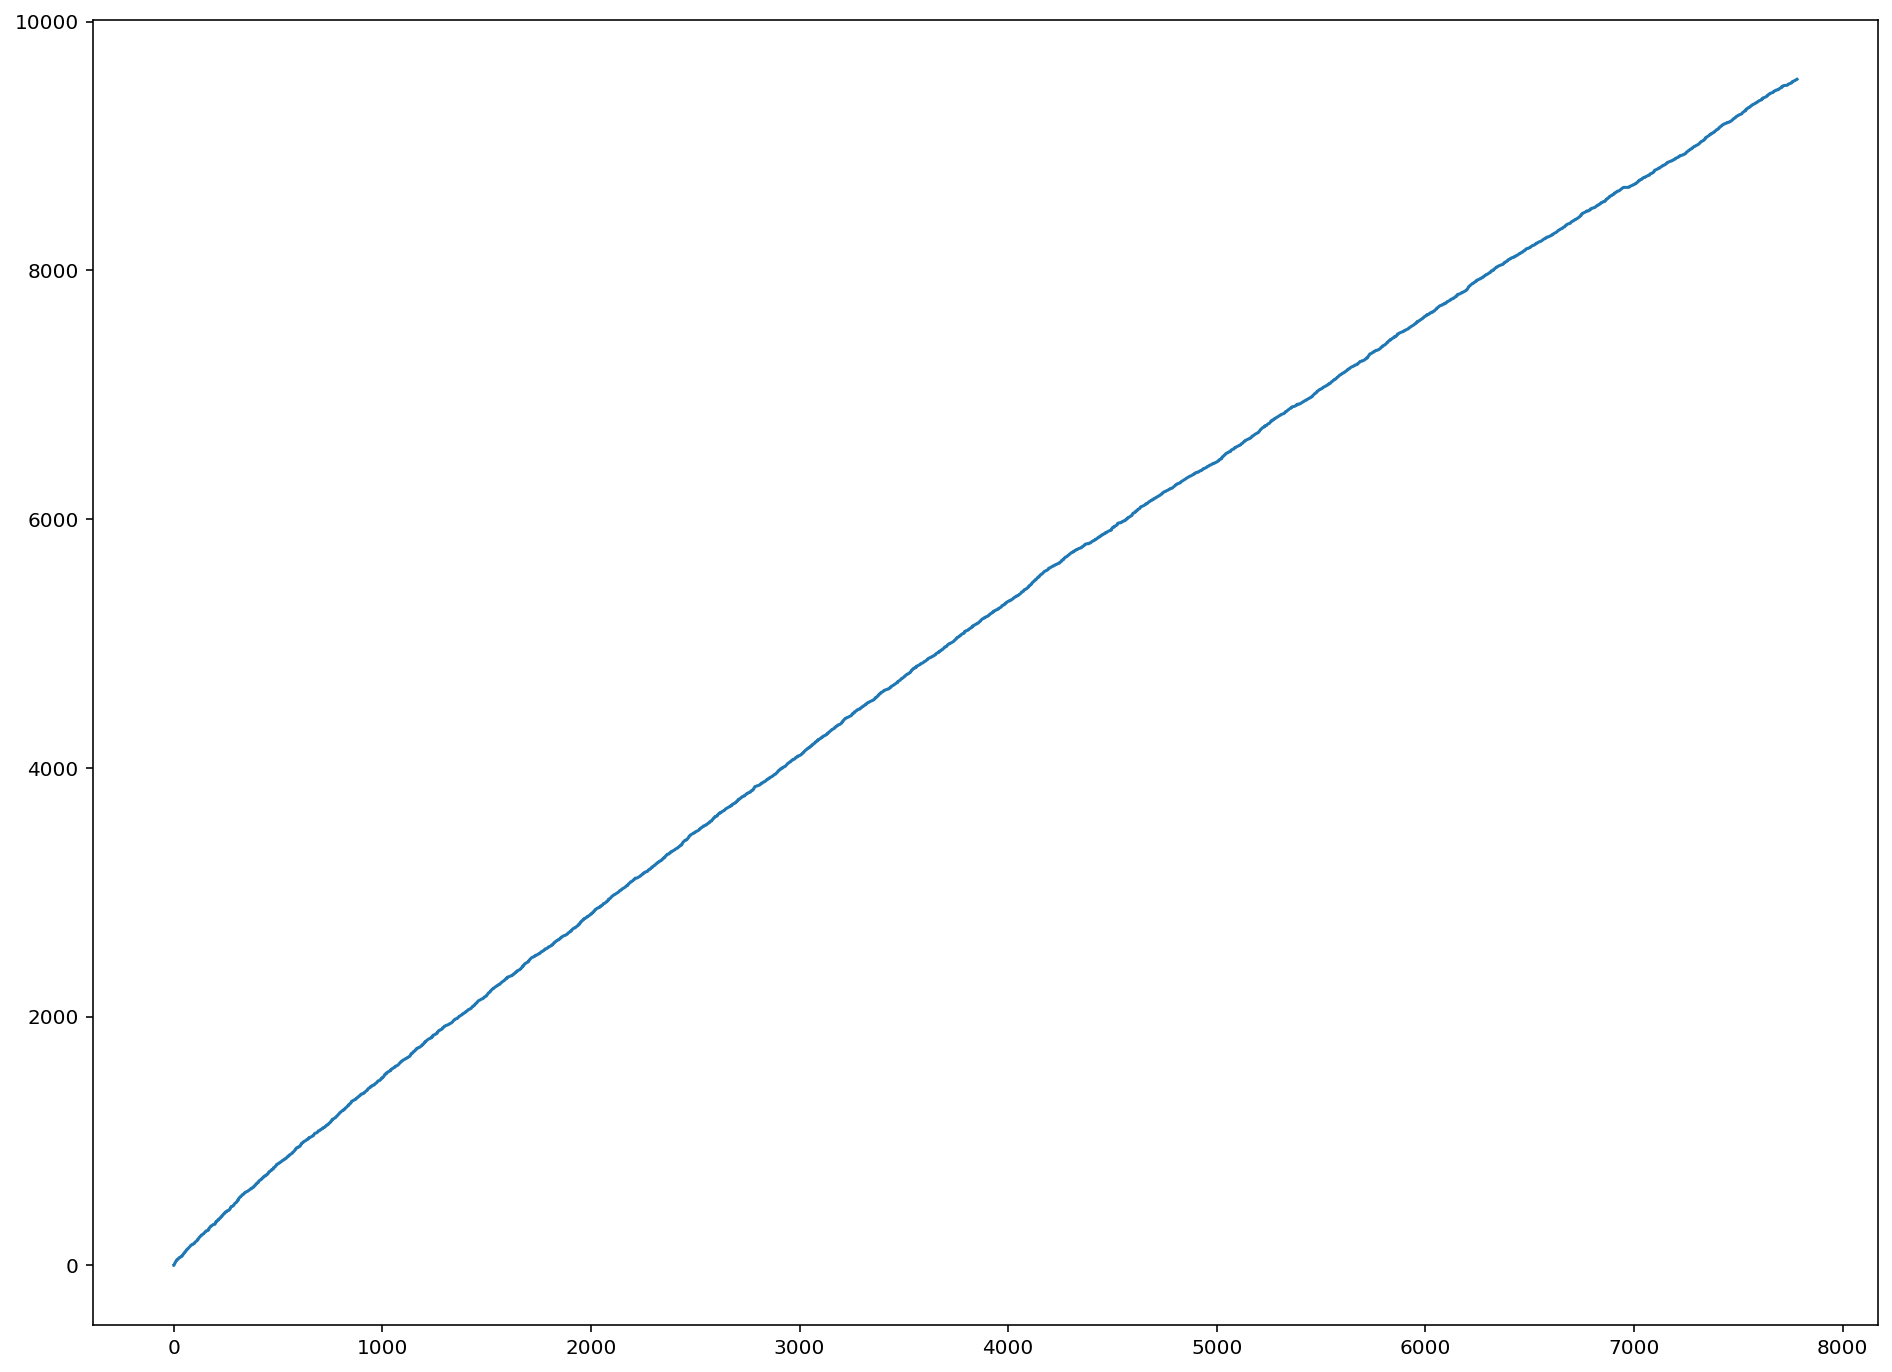

In [55]:
# Plotting macrotime
plt.plot(macrotimes[np.where(markers == 0)])
plt.show()

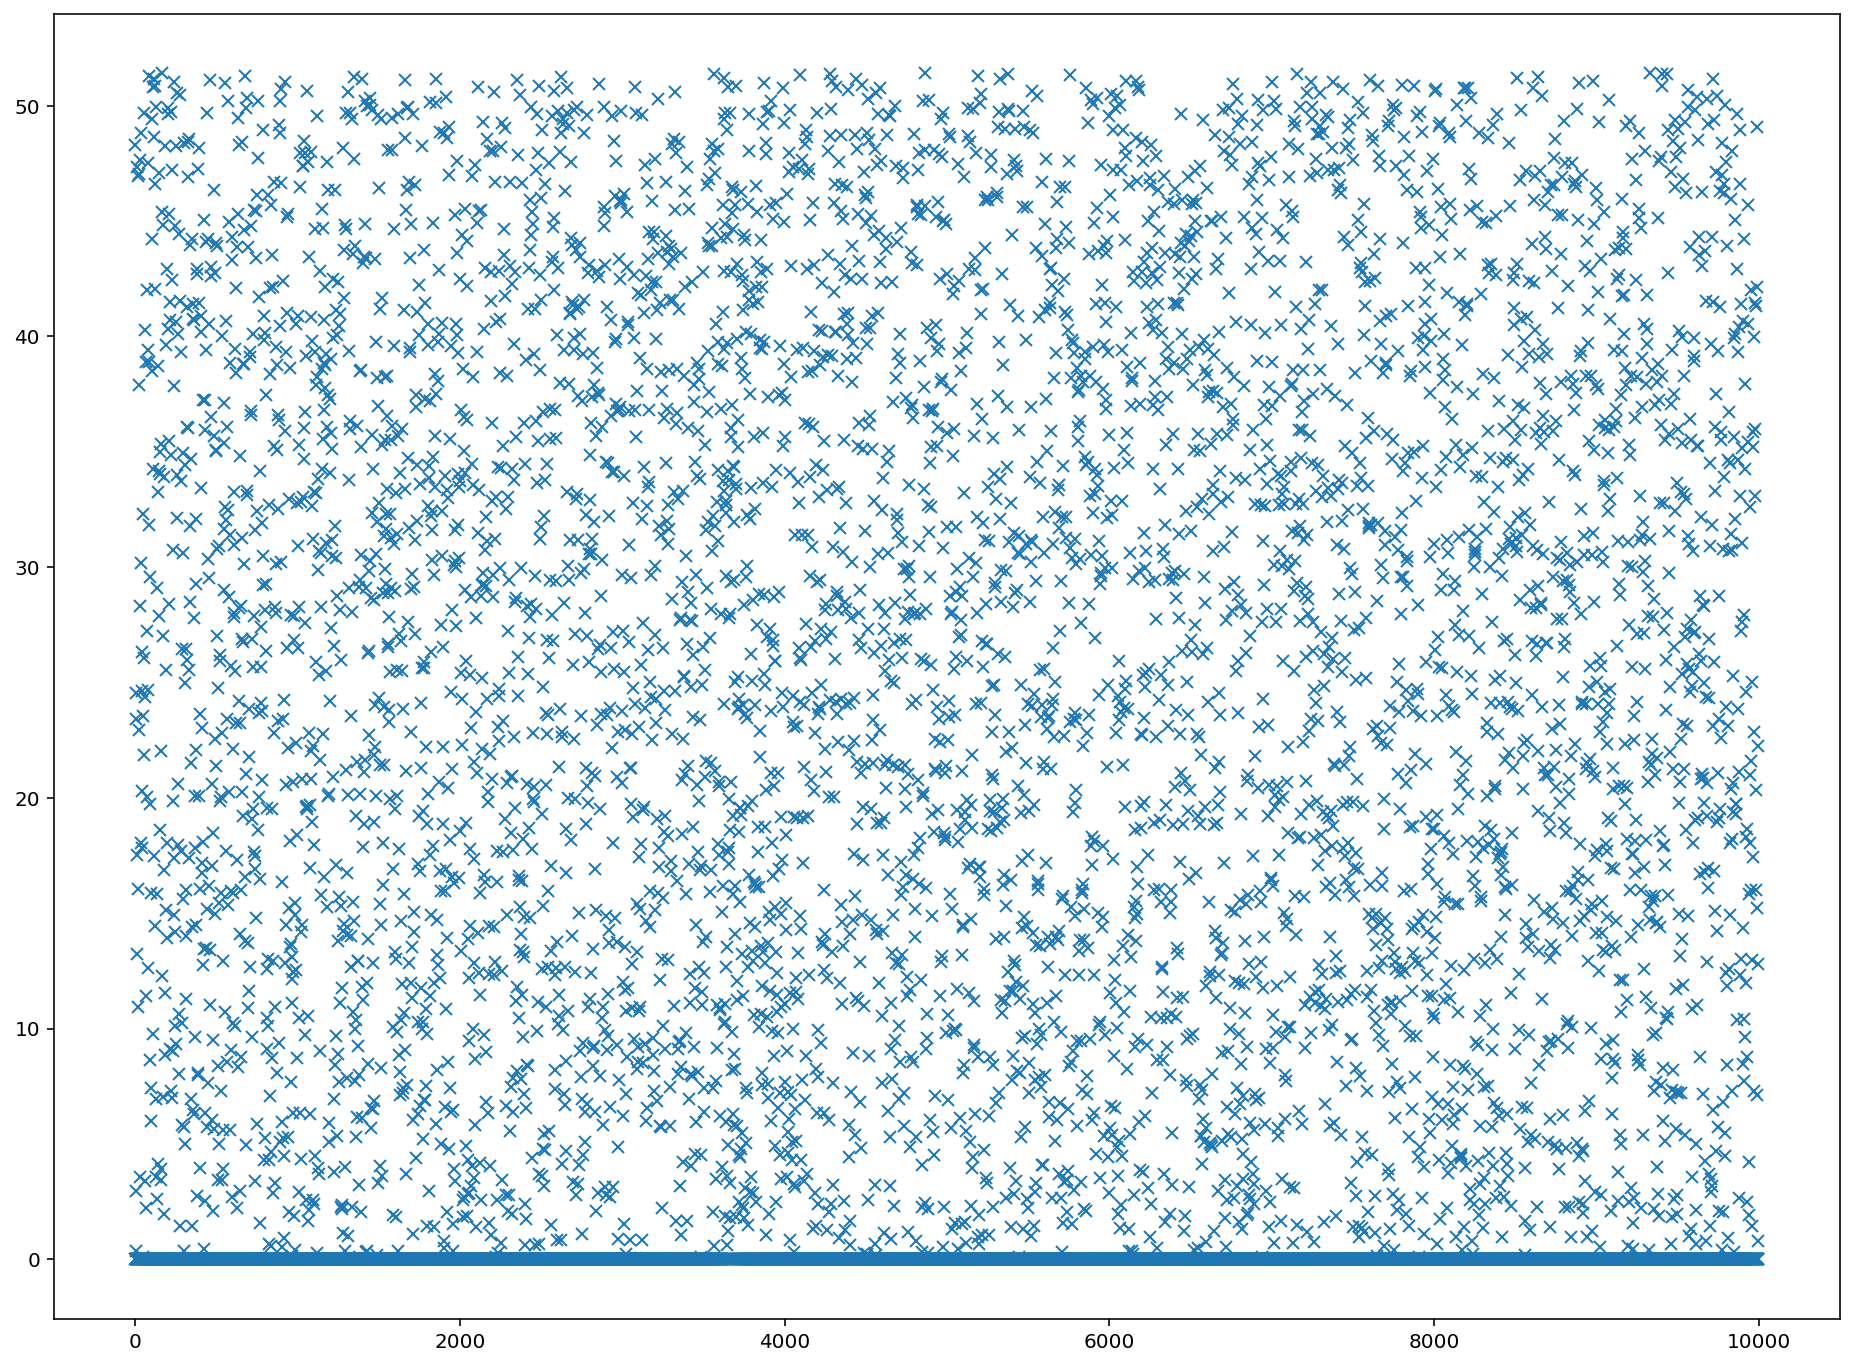

In [46]:
# Plot nanotimes histogram
plt.plot(nanotimes[0:10000], 'x')
plt.show()